In [ ]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Load MATLAB file
mat_data = scipy.io.loadmat('/home/dumindu/modeling/pwdb_data.mat')



<class 'dict'>
dict_keys(['__header__', '__version__', '__globals__', 'data', '__function_workspace__'])
<class 'numpy.ndarray'>
(1, 1)
<class 'numpy.void'>
(392,)
500
392
500
CSV file successfully generated: example_inlet.csv


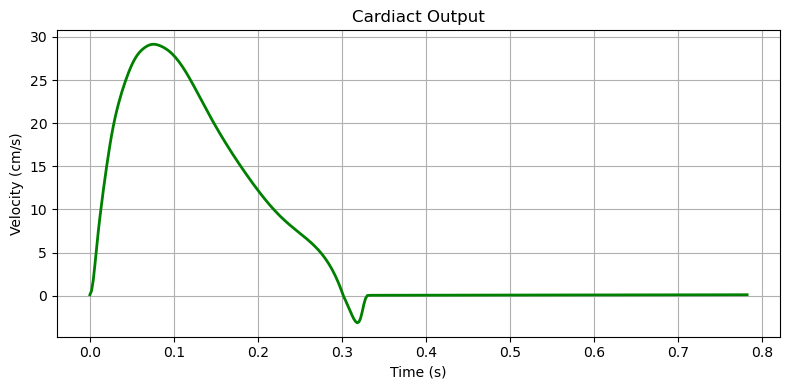

In [10]:
patient = 60

print(type(mat_data))
print(mat_data.keys())
print(type(mat_data['data']))
print(mat_data['data'].shape)
print(type(mat_data['data'][0,0]))
print( np.squeeze(mat_data['data'][0,0]['waves'][0,0]['PPG_AorticRoot'][0,patient]).shape)
# print(mat_data['data'][0]['waves'][0]['A_AorticRoot'][0,0][0,40].shape)

cross_section = np.array(np.squeeze(mat_data['data'][0,0]['waves'][0,0]['A_Brachial'][0,patient]))
velocity = np.array(np.squeeze(mat_data['data'][0,0]['waves'][0,0]['U_Brachial'][0,patient]))
pressure = np.array(np.squeeze(mat_data['data'][0,0]['waves'][0,0]['P_Brachial'][0,patient]))
PPG = np.array(np.squeeze(mat_data['data'][0,0]['waves'][0,0]['PPG_Brachial'][0,patient]))

CO = 100*np.array(np.squeeze(mat_data['data'][0,0]['waves'][0,0]['U_AorticRoot'][0,patient]))

Diameter = np.sqrt((4/np.pi) * cross_section)

# Assuming you have the sampling frequency (fs) available
fs = mat_data['data'][0,0]['waves'][0,0]['fs'][0][0]

print(fs)

# Calculate time vector based on the number of samples and sampling frequency
num_samples = len(CO)
print(num_samples)
time = np.arange(num_samples) / fs

print(fs)
# Plotting the waveforms
fig, axs = plt.subplots(1, 1, figsize=(8, 4))

# axs[0].plot(time, Diameter, 'b', linewidth=2)
# axs[0].set_title('Cross Section Diameter Waveform')
# axs[0].set_xlabel('Time (s)')
# axs[0].set_ylabel('Cross Section Diameter (m)')
# axs[0].grid(True)

# axs[1].plot(time, velocity, 'g', linewidth=2)
# axs[1].set_title('Velocity Waveform')
# axs[1].set_xlabel('Time (s)')
# axs[1].set_ylabel('Velocity (m/s)')
# axs[1].grid(True)

# axs[2].plot(time, pressure, 'r', linewidth=2)
# axs[2].set_title('Pressure Waveform')
# axs[2].set_xlabel('Time (s)')
# axs[2].set_ylabel('Pressure (mmHg)')
# axs[2].grid(True)

new_num_samples = 145
new_time = np.linspace(time[0], time[-1], new_num_samples)
new_velocity = np.interp(new_time, time, velocity)

# Plotting the resampled waveforms
# new_velocity = 100*(new_velocity+abs(np.min(new_velocity)))
new_velocity = 100*new_velocity

# axs[3].plot(new_time, new_velocity, 'g', linewidth=2)
# axs[3].set_title('Velocity Waveform (Resampled)')
# axs[3].set_xlabel('Time (s)')
# axs[3].set_ylabel('new Velocity (cm/s)')
# axs[3].grid(True)

axs.plot(time, CO, 'g', linewidth=2)
axs.set_title('Cardiact Output')
axs.set_xlabel('Time (s)')
axs.set_ylabel('Velocity (cm/s)')
axs.grid(True)



# Save data to CSV file
with open('example_inlet.csv', 'w') as file:
    for i in range(len(new_time)):
        file.write(f'{np.round(new_time[i],6)}, {np.round(new_velocity[i],6)}\n')

print('CSV file successfully generated: example_inlet.csv')
plt.tight_layout()
plt.show()